**Import Libraries**


In [163]:
import pandas as pd
import matplotlib.pyplot as plt
from fontTools.misc.cython import returns
from sklearn.feature_extraction.text import TfidfVectorizer
from codecarbon import EmissionsTracker
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve



**Read Data**

In [164]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train['user_id'] = train['user_id'].str[1:].astype(int)
test['user_id'] = test['user_id'].str[1:].astype(int)



**Drop Null Values and Duplicates**

In [165]:
train = train.dropna()
test = test.dropna()

train = train.drop_duplicates()
test = test.drop_duplicates()



**Balance the Dataset**

In [166]:
ones = train[train['label'] == 1]
zeros = train[train['label'] == 0]

zeros = zeros.sample(n=len(ones), random_state=42)
train = pd.concat([ones, zeros], axis=0).reset_index(drop=True)



**Vectorize the Text Data**

In [167]:
tracker = EmissionsTracker()
tracker.start()
vectorizer = TfidfVectorizer(max_features=5000)
text_features = vectorizer.fit_transform(train['text'])
text_features_test = vectorizer.transform(test['text'])


X_train = hstack([train[['user_id']], text_features])
X_test = hstack([test[['user_id']], text_features_test])
y_train = train['label']
y_test = test['label']


[codecarbon INFO @ 18:37:28] [setup] RAM Tracking...
[codecarbon INFO @ 18:37:28] [setup] CPU Tracking...
[codecarbon WARNING @ 18:37:29] No CPU tracking mode found. Falling back on CPU constant mode. 
 Mac OS and ARM processor detected: Please enable PowerMetrics sudo to measure CPU

[codecarbon INFO @ 18:37:29] CPU Model on constant consumption mode: Apple M1 Pro
[codecarbon INFO @ 18:37:29] [setup] GPU Tracking...
[codecarbon INFO @ 18:37:29] No GPU found.
[codecarbon INFO @ 18:37:29] >>> Tracker's metadata:
[codecarbon INFO @ 18:37:29]   Platform system: macOS-15.1.1-arm64-arm-64bit
[codecarbon INFO @ 18:37:29]   Python version: 3.12.9
[codecarbon INFO @ 18:37:29]   CodeCarbon version: 2.8.3
[codecarbon INFO @ 18:37:29]   Available RAM : 16.000 GB
[codecarbon INFO @ 18:37:29]   CPU count: 10
[codecarbon INFO @ 18:37:29]   CPU model: Apple M1 Pro
[codecarbon INFO @ 18:37:29]   GPU count: None
[codecarbon INFO @ 18:37:29]   GPU model: None
[codecarbon INFO @ 18:37:32] Saving emission

**Train the Model**

In [168]:

lr = LogisticRegression(max_iter=1000, random_state=42, verbose=2, solver='liblinear')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)




# emissions = ≈ 93.59 mg CO₂ 
# electricity =  0.003111 kWh About 1/3 of a phone charge


[LibLinear]iter  1 act 1.595e+00 pre 1.595e+00 delta 4.333e-08 f 1.591e+06 |g| 7.364e+07 CG   1
cg reaches trust region boundary
iter  2 act 9.819e-04 pre 9.818e-04 delta 1.733e-07 f 1.591e+06 |g| 2.286e+04 CG   1
cg reaches trust region boundary
iter  3 act 3.972e-03 pre 3.972e-03 delta 6.933e-07 f 1.591e+06 |g| 1.757e+05 CG   2
cg reaches trust region boundary
iter  4 act 1.584e-02 pre 1.584e-02 delta 2.773e-06 f 1.591e+06 |g| 2.306e+04 CG   2
cg reaches trust region boundary
iter  5 act 6.341e-02 pre 6.341e-02 delta 1.109e-05 f 1.591e+06 |g| 1.757e+05 CG   2
cg reaches trust region boundary
iter  6 act 2.536e-01 pre 2.536e-01 delta 4.437e-05 f 1.591e+06 |g| 2.306e+04 CG   2
cg reaches trust region boundary
iter  7 act 1.014e+00 pre 1.014e+00 delta 1.775e-04 f 1.591e+06 |g| 1.757e+05 CG   2
cg reaches trust region boundary
iter  8 act 4.058e+00 pre 4.058e+00 delta 7.099e-04 f 1.591e+06 |g| 2.306e+04 CG   2
cg reaches trust region boundary
iter  9 act 1.623e+01 pre 1.623e+01 delta 2.8

[codecarbon INFO @ 18:39:19] Energy consumed for RAM : 0.000177 kWh. RAM Power : 6.0 W
[codecarbon INFO @ 18:39:19] Energy consumed for all CPUs : 0.000148 kWh. Total CPU Power : 5.0 W
[codecarbon INFO @ 18:39:19] 0.000325 kWh of electricity used since the beginning.


cg reaches trust region boundary
iter 24 act 7.545e+04 pre 6.825e+04 delta 3.901e+01 f 1.108e+06 |g| 1.554e+04 CG   7
iter 25 act 2.358e+01 pre 2.359e+01 delta 3.901e+01 f 1.033e+06 |g| 2.262e+08 CG   1
iter 26 act 8.707e-06 pre 8.791e-06 delta 3.901e+01 f 1.033e+06 |g| 1.380e+05 CG   1
cg reaches trust region boundary
iter 27 act 5.127e+04 pre 5.521e+04 delta 3.901e+01 f 1.033e+06 |g| 6.685e+03 CG   9
iter 28 act 1.160e+01 pre 1.160e+01 delta 3.901e+01 f 9.815e+05 |g| 1.551e+08 CG   1
iter 29 act 4.478e-06 pre 4.426e-06 delta 3.901e+01 f 9.815e+05 |g| 9.563e+04 CG   1
cg reaches trust region boundary
iter 30 act 3.396e+04 pre 4.471e+04 delta 3.901e+01 f 9.815e+05 |g| 5.191e+03 CG  15
iter 31 act 3.080e-01 pre 3.080e-01 delta 3.901e+01 f 9.476e+05 |g| 2.453e+07 CG   1
cg reaches trust region boundary
iter 32 act -8.302e+03 pre 2.603e+04 delta 1.680e+01 f 9.476e+05 |g| 4.053e+03 CG  14
cg reaches trust region boundary
iter 32 act 1.233e+04 pre 1.448e+04 delta 1.680e+01 f 9.476e+05 |g| 4

**Evaluate the Model**

In [169]:
y_pred = lr.predict_proba(X_test)[:, 1]
test['pred'] = y_pred
auc = roc_auc_score(y_test, y_pred)

print(f"AUC-ROC Score: {auc:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred > 0.2):.4f}")
print(classification_report(y_test, y_pred > 0.2))

AUC-ROC Score: 0.7799
Accuracy: 0.4854
              precision    recall  f1-score   support

           0       0.92      0.21      0.34   2367819
           1       0.41      0.97      0.58   1370140

    accuracy                           0.49   3737959
   macro avg       0.67      0.59      0.46   3737959
weighted avg       0.73      0.49      0.43   3737959



In [170]:
test[test['user_id'] == 44035]



,user_id,text,label,news_id,pred
45407,44035,news newsworld princ andrew say let royal fami...,0,N16396,0.436623
134925,44035,foodanddrink video cake boss made carlo 's bak...,0,N24675,0.819431
184768,44035,tv tv-celebr alex rodriguez jokingli talk abou...,0,N46749,0.924096
243239,44035,news newspolit judg fast-track case former whi...,1,N15603,0.475033
320222,44035,news newspolit roger stone is convict imped in...,0,N64077,0.873344
...,...,...,...,...,...
3286656,44035,sport icehockey_nhl brown garrett n't athlet u...,0,N35676,0.694387
3297826,44035,entertain entertainment-celebr the latest brad...,0,N48487,0.259748
3477257,44035,travel travelnew greek donkey still abus 'tour...,0,N65145,0.309122
3520549,44035,sport football_nfl report at least 24 team exp...,0,N56080,0.169510


In [174]:
import math # For log2 in NDCG
from random import randint
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
import time
from tqdm import tqdm # For progress bars
import warnings
from sklearn.metrics import roc_auc_score

BEHAVIORS_HEADER = ["impression_id", "user_id", "time", "history", "impressions"]

# --- Helper Functions for Metrics ---

def calculate_mrr(ranked_list, relevant_set):
    """Calculates Mean Reciprocal Rank for a single ranked list."""
    for i, item in enumerate(ranked_list):
        if item in relevant_set:
            return 1.0 / (i + 1.0) # Rank is 1-based
    return 0.0

def calculate_dcg(ranked_list, relevant_set, k):
    """Calculates Discounted Cumulative Gain @ k."""
    dcg = 0.0
    for i, item in enumerate(ranked_list[:k]):
        if item in relevant_set:
            # Relevance is 1 if clicked, 0 otherwise
            relevance = 1.0
            dcg += relevance / math.log2(i + 2.0) # log base 2, rank is i+1, denominator is log2(rank+1)
    return dcg

def calculate_ndcg(ranked_list, relevant_set, k):
    """Calculates Normalized Discounted Cumulative Gain @ k."""
    if not relevant_set: # Should not happen if we filter impressions, but safety check
        return 0.0

    dcg_at_k = calculate_dcg(ranked_list, relevant_set, k)

    # Calculate Ideal DCG (IDCG)
    ideal_ranked_list = sorted(list(relevant_set), key=lambda x: 1, reverse=True) # Simulate ideal ranking
    # In this case, relevance is always 1 for items in relevant_set
    idcg_at_k = calculate_dcg(ideal_ranked_list, relevant_set, k)

    if idcg_at_k == 0:
        return 0.0 # Avoid division by zero; happens if no relevant items are in top k of ideal list (or relevant_set is empty)
    else:
        return dcg_at_k / idcg_at_k


def calculate_precision_recall_f1_at_k(ranked_list, relevant_set, k):
    """Calculates Precision@k, Recall@k, and F1@k."""
    if not relevant_set: # Should not happen if we filter impressions, but safety
        return 0.0, 0.0, 0.0

    top_k_items = set(ranked_list[:k])
    relevant_in_top_k = top_k_items.intersection(relevant_set)
    num_relevant_in_top_k = len(relevant_in_top_k)

    precision_at_k = num_relevant_in_top_k / k if k > 0 else 0.0
    recall_at_k = num_relevant_in_top_k / len(relevant_set) # len(relevant_set) > 0 here

    if precision_at_k + recall_at_k == 0:
        f1_at_k = 0.0
    else:
        f1_at_k = 2 * (precision_at_k * recall_at_k) / (precision_at_k + recall_at_k)

    return precision_at_k, recall_at_k, f1_at_k

# --- Recommender Class ---

def weighted_average(first_value, df, weight_first=0.5, weight_second=0.5):
    # Check if the first value is between 0 and 1
    if not (0 <= first_value <= 1):
        first_value_valid = False
    else:
        first_value_valid = True

    # Check if the DataFrame is valid (not empty)
    if df.empty or "pred" not in df.columns:
        second_value_valid = False
    else:
        # Check if the "news_id" value is valid
        second_value_valid = not df["pred"].isna().iloc[0]  # Ensure it's not NaN or None

    # Determine the weighting and final value
    if first_value_valid and second_value_valid:
        # Both values are valid, apply weighted average
        weighted_avg = (first_value * weight_first + df["pred"].iloc[0] * weight_second) / (weight_first + weight_second)
        #print("weighted")
    elif first_value_valid:
        # Only the first value is valid, use it
        weighted_avg = first_value
    elif second_value_valid:
        # Only the second value is valid, use it
        weighted_avg = df["pred"].iloc[0]
        #print("updated")
    else:
        # Neither value is valid, default to the first_value
        weighted_avg = first_value

    return weighted_avg


class GeneralCosineSimilarityRecommender:
    def __init__(self, df=None):
        print("Initializing Recommender...")
        self.train_df = df # Rename to be specific
        self.similarity_matrix = None
        self.interaction_matrix = None
        self.article_id_to_idx = {}
        self.idx_to_article_id = {}
        self.user_id_to_idx = {}
        self.idx_to_user_id = {}
        self.known_items = set() # Keep track of items seen during training

    def load_data(self, path=None):
        print(f"Loading training data from: {path}")
        if path is None:
            raise ValueError("Path cannot be None")
        self.train_df = pd.read_csv(path, sep="\t", names=BEHAVIORS_HEADER)
        print(f"Training data loaded. Shape: {self.train_df.shape}")
        return self.train_df

    def preprocess(self):
        # --- This preprocessing is for the TRAINING data ---
        print("Preprocessing training data...")
        start_time = time.time()
        df = self.train_df # Work with train_df

        initial_rows = len(df)
        df = df.drop_duplicates(subset='impression_id')
        df = df.drop_duplicates(subset=['user_id', 'time'])
        df = df.dropna(subset=['user_id', 'time', 'history', 'impressions'])
        rows_after_dedup_na = len(df)
        print(f"  Removed {initial_rows - rows_after_dedup_na} rows (duplicates/NaN).")

        if len(df) == 0:
            print("WARNING: No training data left after initial preprocessing.")
            self.train_df = df
            return self.train_df

        # Parse impressions: Get actual clicks for the interaction matrix
        # We only care about clicks (1) for the interaction matrix here
        def parse_clicks(imp_str):
            clicked = []
            if isinstance(imp_str, str):
                for item in imp_str.split():
                    if len(item) > 2 and item.endswith('-1'):
                        clicked.append(item[:-2])
            return clicked

        df['clicked_articles'] = df['impressions'].apply(parse_clicks)

        # We don't need the full impression string or history for the basic item-CF matrix itself
        # Keep user_id and the clicked articles
        interaction_data = df[['user_id', 'clicked_articles']].explode('clicked_articles').dropna()
        interaction_data.rename(columns={'clicked_articles': 'article_id'}, inplace=True)
        interaction_data['click'] = 1 # Implicitly a click

        print(f"  Found {len(interaction_data)} click interactions.")

        # Create Mappings
        self.user_id_to_idx = {user_id: i for i, user_id in enumerate(interaction_data['user_id'].unique())}
        self.idx_to_user_id = {i: user_id for user_id, i in self.user_id_to_idx.items()}
        self.article_id_to_idx = {article_id: i for i, article_id in enumerate(interaction_data['article_id'].unique())}
        self.idx_to_article_id = {i: article_id for article_id, i in self.article_id_to_idx.items()}
        self.known_items = set(self.article_id_to_idx.keys())

        print(f"  Unique users in train: {len(self.user_id_to_idx)}")
        print(f"  Unique clicked articles in train: {len(self.article_id_to_idx)}")

        # Store processed interactions for matrix creation
        self.processed_interactions = interaction_data

        print(f"Preprocessing finished. Time: {time.time() - start_time:.2f}s")
        # Return the original df if needed elsewhere, though we mainly use processed_interactions now
        self.train_df = df # Keep the original parsed df if history is needed later
        return self.train_df


    def create_interaction_matrix(self):
        print("Creating interaction matrix...")
        start_time = time.time()
        if not hasattr(self, 'processed_interactions') or self.processed_interactions.empty:
            print("ERROR: No processed interactions available. Run preprocess first.")
            return

        rows = self.processed_interactions['user_id'].map(self.user_id_to_idx)
        cols = self.processed_interactions['article_id'].map(self.article_id_to_idx)
        values = self.processed_interactions['click'] # Should be all 1s

        # Filter out any potential mapping errors (though dropna in preprocess should prevent this)
        valid_idx = rows.notna() & cols.notna()
        if not valid_idx.all():
            print(f"WARNING: Found {len(valid_idx) - valid_idx.sum()} invalid user/item mappings. Filtering them out.")
            rows, cols, values = rows[valid_idx], cols[valid_idx], values[valid_idx]


        num_users = len(self.user_id_to_idx)
        num_items = len(self.article_id_to_idx)

        if num_users == 0 or num_items == 0:
            print("WARNING: Zero users or items found. Cannot create matrix.")
            self.interaction_matrix = None
            return

        sparse_interaction_matrix = csr_matrix((values, (rows, cols)), shape=(num_users, num_items))

        # Store the sparse matrix directly
        self.interaction_matrix = sparse_interaction_matrix
        print(f"Interaction matrix created (sparse). Shape: {self.interaction_matrix.shape}. Time: {time.time() - start_time:.2f}s")
        sparsity = 1.0 - (self.interaction_matrix.nnz / float(np.prod(self.interaction_matrix.shape)))
        print(f"  Interaction matrix sparsity: {sparsity:.6f}")


    def create_similarity_matrix(self):
        print("Creating similarity matrix...")
        start_time = time.time()
        if self.interaction_matrix is None:
            print("WARNING: Interaction matrix is not available. Skipping similarity matrix creation.")
            self.similarity_matrix = None
            return

        if self.interaction_matrix.shape[1] < 2:
            print("WARNING: Need at least 2 items to calculate similarity. Skipping.")
            self.similarity_matrix = None
            return

        # Item-Item Cosine Similarity (using the transpose of user-item matrix)
        # interaction_matrix is (users x items)
        # interaction_matrix.T is (items x users)
        item_similarity_sparse = cosine_similarity(self.interaction_matrix.T, dense_output=False)

        # Ensure diagonal is zero (or close to zero due to precision) to avoid self-similarity boosting scores
        item_similarity_sparse = item_similarity_sparse - csr_matrix((item_similarity_sparse.diagonal(), (range(item_similarity_sparse.shape[0]), range(item_similarity_sparse.shape[0]))))

        self.similarity_matrix = item_similarity_sparse # Keep it sparse
        print(f"Similarity matrix created (sparse). Shape: {self.similarity_matrix.shape}. Time: {time.time() - start_time:.2f}s")


    def predict_scores_for_candidates(self, user_id, candidate_items):
        """
        Predicts recommendation scores for a specific list of candidate items for a given user.
        Scores are based on item similarity to the user's *training* history.
        """
        # Check if model components are ready
        if self.interaction_matrix is None or self.similarity_matrix is None:
            # print(f"Warning: Model not ready for predictions for user {user_id}.")
            return {} # Return empty dict if model not trained

        # Check if user exists in the training data
        if user_id not in self.user_id_to_idx:
            # print(f"User {user_id} not found in training data.")
            return {} # Return empty dict if user is unknown

        user_idx = self.user_id_to_idx[user_id]

        # Get user's interaction vector (sparse row from the training matrix)
        user_vector = self.interaction_matrix[user_idx, :] # This is a sparse row vector (1 x num_items)

        # Calculate scores: User Vector (1 x Items) @ Similarity Matrix (Items x Items) -> Scores (1 x Items)
        # Note: similarity_matrix is Item x Item, so we need user_vector @ similarity_matrix
        try:
            # Ensure similarity matrix is CSR for efficient row slicing if needed later, though dot product works well
            if not isinstance(self.similarity_matrix, csr_matrix):
                self.similarity_matrix = self.similarity_matrix.tocsr()

            # Calculate scores for ALL items
            all_scores_vector = user_vector.dot(self.similarity_matrix) # Result is typically a dense numpy array (1 x num_items)

            # If all_scores_vector is sparse, convert to dense array
            if not isinstance(all_scores_vector, np.ndarray):
                all_scores_vector = all_scores_vector.toarray().flatten() # Flatten to 1D array
            else:
                all_scores_vector = all_scores_vector.flatten()


        except Exception as e:
            print(f"Error during score calculation for user {user_id}: {e}")
            return {}

        # --- Filter scores for candidate items ONLY ---
        candidate_scores = {}
        for item_id in candidate_items:
            if item_id in self.article_id_to_idx:
                item_idx = self.article_id_to_idx[item_id]
                # Get the score for this item index
                score = all_scores_vector[item_idx]

                # Optional: Check if this item was in the user's training history.
                # If so, maybe set score to -inf or very low? Let's keep it simple for now
                # and *not* filter here, as we're just ranking the candidates provided.
                # The similarity calculation already implicitly handles this (items similar to history).

                candidate_scores[item_id] = score
            else:
                # Candidate item not seen during training, assign a very low score
                candidate_scores[item_id] = -np.inf # Or 0, or some other default low value

        return candidate_scores

    def evaluate_impression_ranking(self, test_behaviors_path, k_list=[5, 10], limit=None):
        """
        Evaluates the model using impression-based ranking metrics
        (MRR, NDCG@k, Precision@k, Recall@k, F1@k, AUC).
        """
        print(f"\nEvaluating model with impression ranking on: {test_behaviors_path}")
        start_time = time.time()

        try:
            test_df = pd.read_csv(test_behaviors_path, sep="\t", names=BEHAVIORS_HEADER,
                                  usecols=['user_id', 'impressions'])
            test_df = test_df.dropna()
        except Exception as e:
            print(f"ERROR loading test data: {e}")
            return {}

        if limit is not None:
            print(f"  Limiting evaluation to first {limit} impressions.")
            test_df = test_df.head(limit)

        if test_df.empty:
            print("No test data to evaluate.")
            return {}

        # Initialize lists for storing metrics per impression
        mrr_scores = []
        auc_scores = []
        # Use dictionaries to store lists for each k
        ndcg_scores = {k: [] for k in k_list}
        precision_scores = {k: [] for k in k_list}
        recall_scores = {k: [] for k in k_list}
        f1_scores = {k: [] for k in k_list}

        impressions_processed = 0
        impressions_skipped_user = 0
        impressions_skipped_noclick = 0
        impressions_skipped_allclicked = 0 # For AUC
        impressions_evaluated = 0

        print("Processing test impressions...")
        for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Evaluating"):
            impressions_processed += 1
            user_id = row['user_id']
            impression_str = row['impressions']

            if user_id not in self.user_id_to_idx:
                impressions_skipped_user += 1
                continue

            candidates = []
            clicked_in_impression = set()
            candidate_labels = {} # Store label (0/1) for AUC
            if isinstance(impression_str, str):
                for item in impression_str.split():
                    if len(item) > 2 and item[-2:] in ['-1', '-0']:
                        article_id = item[:-2]
                        is_clicked = item.endswith('-1')
                        candidates.append(article_id)
                        candidate_labels[article_id] = 1 if is_clicked else 0
                        if is_clicked:
                            clicked_in_impression.add(article_id)

            if not clicked_in_impression:
                impressions_skipped_noclick += 1
                continue

            # --- Get Scores and Rank ---
            candidate_scores = self.predict_scores_for_candidates(user_id, candidates)

            user_df = test[test['user_id'] == int(row['user_id'][1:])]

            for candidate in candidates:
                filtered_df = user_df[user_df['news_id'] == candidate]
                candidate_scores[candidate] = weighted_average(candidate_scores[candidate], filtered_df)
                #print(filtered_df)
                #print(candidate_scores[candidate])
                #print(candidate_scores[candidate])

            ranked_candidates = sorted(
                candidates,
                key=lambda item: candidate_scores.get(item, -np.inf),
                reverse=True
            )

            # --- Calculate Metrics for this impression ---
            impressions_evaluated += 1 # Count this impression for MRR, NDCG, P/R/F1

            # MRR
            mrr = calculate_mrr(ranked_candidates, clicked_in_impression)
            mrr_scores.append(mrr)

            # NDCG, Precision, Recall, F1 @ k
            for k in k_list:
                # NDCG
                ndcg_k = calculate_ndcg(ranked_candidates, clicked_in_impression, k)
                ndcg_scores[k].append(ndcg_k)
                # P, R, F1
                p_k, r_k, f1_k = calculate_precision_recall_f1_at_k(
                    ranked_candidates, clicked_in_impression, k
                )
                precision_scores[k].append(p_k)
                recall_scores[k].append(r_k)
                f1_scores[k].append(f1_k)

            # AUC
            # Requires at least one positive and one negative example in the impression
            num_positives = len(clicked_in_impression)
            num_negatives = len(candidates) - num_positives

            if num_positives > 0 and num_negatives > 0:
                y_true = [candidate_labels[item] for item in candidates]
                y_score = [candidate_scores.get(item, -np.inf) for item in candidates]

                try:
                    # Ignore warnings like "Only one class present in y_true." (shouldn't happen due to checks)
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        auc = roc_auc_score(y_true, y_score)
                    auc_scores.append(auc)
                except ValueError as e:
                    # This might happen in rare cases sklearn doesn't handle gracefully
                    print(f"\nWarning: Could not calculate AUC for an impression (User: {user_id}). Error: {e}")
                    # Optionally append NaN or skip this impression for AUC averaging
                    #auc_scores.append(np.nan) # If you want to keep track but ignore in mean
            elif num_positives == len(candidates): # All items were clicked
                impressions_skipped_allclicked +=1
                # AUC is undefined (or 1.0 depending on definition), skip averaging
                pass

        # --- Aggregate Results ---
        print("\nEvaluation Summary:")
        print(f"  Total impressions processed: {impressions_processed}")
        print(f"  Impressions skipped (user not in train): {impressions_skipped_user}")
        print(f"  Impressions skipped (no clicks): {impressions_skipped_noclick}")
        print(f"  Impressions skipped (all items clicked - for AUC): {impressions_skipped_allclicked}")
        print(f"  Impressions evaluated (for MRR/NDCG/P/R/F1): {impressions_evaluated}")
        print(f"  Impressions used for AUC average: {len(auc_scores)}")


        if impressions_evaluated == 0:
            print("No impressions were fully evaluated.")
            return {}

        final_metrics = {}

        # Average MRR
        avg_mrr = np.mean(mrr_scores) if mrr_scores else 0.0
        print(avg_mrr)
        final_metrics['MRR'] = avg_mrr

        # Average AUC
        avg_auc = np.mean(auc_scores) if auc_scores else 0.0 # Excludes impressions where AUC couldn't be calculated
        print(avg_auc)
        final_metrics['AUC'] = avg_auc

        # Average k-based metrics
        for k in k_list:
            final_metrics[f'NDCG@{k}'] = np.mean(ndcg_scores[k]) if ndcg_scores[k] else 0.0
            final_metrics[f'Precision@{k}'] = np.mean(precision_scores[k]) if precision_scores[k] else 0.0
            final_metrics[f'Recall@{k}'] = np.mean(recall_scores[k]) if recall_scores[k] else 0.0
            final_metrics[f'F1@{k}'] = np.mean(f1_scores[k]) if f1_scores[k] else 0.0

        print(f"\nEvaluation finished. Total time: {time.time() - start_time:.2f}s")
        return final_metrics


    def print_results(self, metrics):
        print("\n--- Evaluation Results ---")
        if not metrics:
            print("No metrics calculated.")
            return

        # Print single value metrics first
        if 'AUC' in metrics: print(f"AUC:       {metrics['AUC']:.4f}")
        if 'MRR' in metrics: print(f"MRR:       {metrics['MRR']:.4f}")

        # Group k-based metrics
        k_metrics_found = False
        sorted_keys = sorted([key for key in metrics if '@' in key], key=lambda x: (int(x.split('@')[1]), x.split('@')[0]))

        current_k = -1
        for key in sorted_keys:
            metric_name, k_str = key.split('@')
            k = int(k_str)
            if k != current_k:
                if k_metrics_found: print("-" * 15) # Separator
                print(f"Metrics @{k}:")
                current_k = k
                k_metrics_found = True
            print(f"  {metric_name:<10}: {metrics[key]:.4f}")

        if not k_metrics_found and 'AUC' not in metrics and 'MRR' not in metrics:
            print("No standard metrics found in results.") # Fallback

        print("--------------------------")

    def recommend_items_to_user(self, user_id, num_recommendations=10):
        """
        Generates item recommendations for a specific user based on the trained model.
        Returns a list of recommended item IDs.
        """
        # Check if model components are ready
        if self.interaction_matrix is None or self.similarity_matrix is None:
            print(f"Warning: Model not ready for recommendations for user {user_id}.")
            return []

        # Check if user exists in the training data
        if user_id not in self.user_id_to_idx:
            print(f"User {user_id} not found in training data.")
            return []
        # Get scores for all items
        candidate_items = list(self.article_id_to_idx.keys())
        candidate_scores = self.predict_scores_for_candidates(user_id, candidate_items)
        # Rank candidates based on scores
        ranked_candidates = sorted(candidate_items, key=lambda item: candidate_scores.get(item, -np.inf), reverse=True)
        # Get top N recommendations
        top_recommendations = ranked_candidates[:num_recommendations]
        # Map back to original article IDs
        recommended_article_ids = [self.idx_to_article_id[self.article_id_to_idx[item]] for item in top_recommendations]
        return recommended_article_ids



In [175]:
# Define file paths
TRAIN_PATH = "./behaviors.tsv"
TEST_PATH = "./test_behaviors.tsv"
EVAL_LIMIT = None # Evaluate on first N impressions (set to None for all)
K_VALUES = [5, 10, 20] # K for NDCG@k

# --- Training Phase ---
recommender = GeneralCosineSimilarityRecommender()
recommender.load_data(TRAIN_PATH)
recommender.preprocess()
recommender.create_interaction_matrix()
recommender.create_similarity_matrix()

# Check if model training was successful before evaluation
if recommender.interaction_matrix is None or recommender.similarity_matrix is None:
    print("\nModel training failed (interaction or similarity matrix missing). Skipping evaluation.")


# --- Evaluation Phase ---
evaluation_metrics = recommender.evaluate_impression_ranking(
    test_behaviors_path=TEST_PATH,
    k_list=K_VALUES,
    limit=EVAL_LIMIT
)

emissions = tracker.stop()
print(f"Emissions: {emissions} kg CO2eq")

recommender.print_results(evaluation_metrics)

# --- Recommendation Phase ---
user_id = 'U10306' # Example user ID
num_recommendations = 10
recommendations = recommender.recommend_items_to_user(user_id, num_recommendations)
print(f"\nRecommendations for User {user_id}:")
print(recommendations)

Initializing Recommender...
Loading training data from: ./behaviors.tsv
Training data loaded. Shape: (156965, 5)
Preprocessing training data...
  Removed 3255 rows (duplicates/NaN).
  Found 231501 click interactions.
  Unique users in train: 49108
  Unique clicked articles in train: 7659
Preprocessing finished. Time: 1.47s
Creating interaction matrix...
Interaction matrix created (sparse). Shape: (49108, 7659). Time: 0.03s
  Interaction matrix sparsity: 0.999389
Creating similarity matrix...
Similarity matrix created (sparse). Shape: (7659, 7659). Time: 0.04s

Evaluating model with impression ranking on: ./test_behaviors.tsv
Processing test impressions...


Evaluating: 100%|██████████| 73152/73152 [01:31<00:00, 797.41it/s] 
[codecarbon WARNING @ 18:48:40] Tracker already stopped !
[codecarbon WARNING @ 18:48:40] Background scheduler didn't run for a long period (457s), results might be inaccurate
[codecarbon INFO @ 18:48:40] Energy consumed for RAM : 0.001112 kWh. RAM Power : 6.0 W
[codecarbon INFO @ 18:48:40] Energy consumed for all CPUs : 0.000927 kWh. Total CPU Power : 5.0 W
[codecarbon INFO @ 18:48:40] 0.002039 kWh of electricity used since the beginning.



Evaluation Summary:
  Total impressions processed: 73152
  Impressions skipped (user not in train): 64452
  Impressions skipped (no clicks): 0
  Impressions skipped (all items clicked - for AUC): 0
  Impressions evaluated (for MRR/NDCG/P/R/F1): 8700
  Impressions used for AUC average: 8700
0.2593480886120347
0.5054482957573901

Evaluation finished. Total time: 92.06s
Emissions: 6.133304070112089e-05 kg CO2eq

--- Evaluation Results ---
AUC:       0.5054
MRR:       0.2593
Metrics @5:
  F1        : 0.1309
  NDCG      : 0.2340
  Precision : 0.0840
  Recall    : 0.3454
---------------
Metrics @10:
  F1        : 0.1131
  NDCG      : 0.2925
  Precision : 0.0654
  Recall    : 0.5157
---------------
Metrics @20:
  F1        : 0.0889
  NDCG      : 0.3510
  Precision : 0.0483
  Recall    : 0.7247
--------------------------

Recommendations for User U10306:
['N44991', 'N33619', 'N287', 'N35729', 'N50675', 'N63970', 'N62360', 'N19592', 'N23446', 'N47098']


**Plot the Roc Curve**

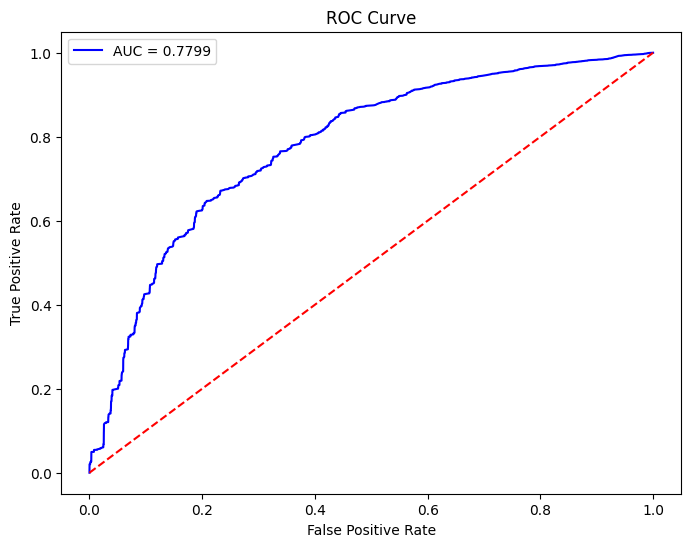

In [173]:
fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", color="blue")
plt.plot([0, 1], [0, 1], 'r--') 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
